In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [34]:
price_data = pd.read_csv("housePricePrediction.csv")
price_data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [35]:
price_data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [36]:
price_data.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [37]:
price_data.shape

(2919, 13)

In [38]:
price_data = price_data.dropna(subset=['SalePrice'])

In [39]:
price_data.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [40]:
price_data.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [41]:
x=price_data[['YearBuilt','LotArea','OverallCond','TotalBsmtSF','YearRemodAdd']]
y=price_data['SalePrice']

In [42]:
x.head()

,YearBuilt,LotArea,OverallCond,TotalBsmtSF,YearRemodAdd
0,2003,8450,5,856.0,2003
1,1976,9600,8,1262.0,1976
2,2001,11250,5,920.0,2002
3,1915,9550,5,756.0,1970
4,2000,14260,5,1145.0,2000


In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [44]:
model= LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred = model.predict(x_test)
y_pred

array([203294.15934487, 231980.13180291, 119087.0325635 , 131984.3416146 ,
       263623.46155039, 132527.44915048, 185980.40593106, 153194.47035985,
       129935.20841866, 140709.49954667, 111683.35155163, 151772.52566362,
       115489.040974  , 247949.82698222, 198042.75680616, 191743.49471695,
       198503.77908631, 190434.31088414, 109168.39882558, 242468.17341512,
       186598.74013884, 200424.01248953, 193321.86230611, 179734.79376414,
       233009.61823338, 206349.17297699, 238802.14375016, 130520.53156201,
       197487.01646573, 233995.73585539, 118528.24907163, 211509.47194179,
       222342.35596379, 143150.85833968, 262026.50624922, 165487.75208369,
       164513.03227605, 198331.03020368, 233522.57820036,  70810.91827175,
       107027.85102433, 198753.07707431, 157148.2059416 , 294477.62215808,
       144649.88501171,  80905.7004815 , 141628.49865962, 157929.62497041,
       272000.48639713, 133573.14887502, 127244.10245953, 209600.61660706,
       114326.91024134, 2

In [46]:
y_test

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
988     195000.0
243     120000.0
1342    228500.0
1057    248000.0
1418    124000.0
Name: SalePrice, Length: 365, dtype: float64

In [47]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

0.572690291520351

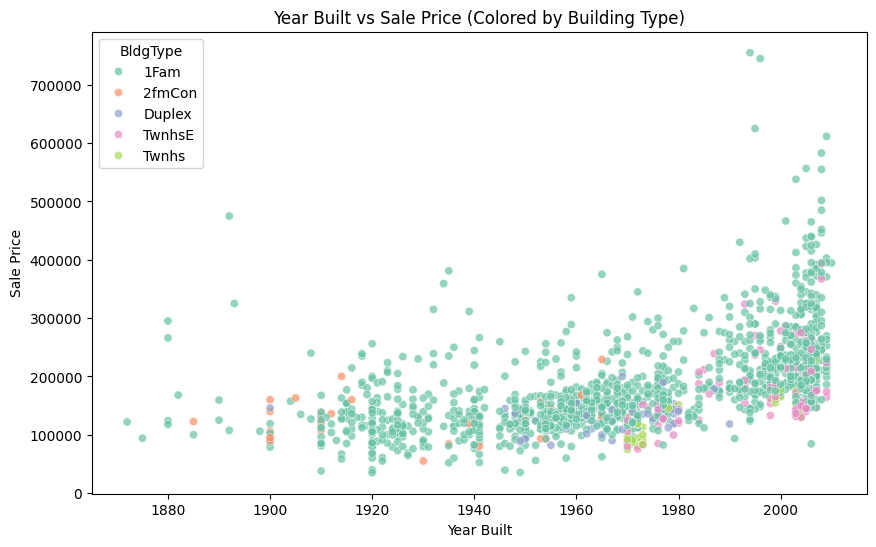

In [54]:
from matplotlib import pyplot as plt


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=price_data, 
    x='YearBuilt', 
    y='SalePrice', 
    hue='BldgType', 
    palette='Set2', 
    alpha=0.7
)
plt.title('Year Built vs Sale Price (Colored by Building Type)')
plt.xlabel('Year Built')
plt.ylabel('Sale Price')
plt.show()

<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

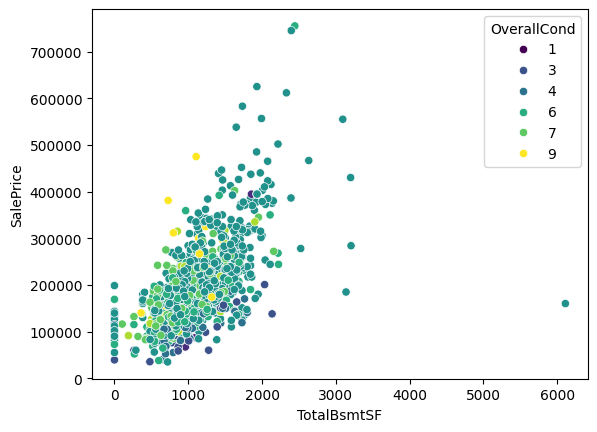

In [51]:
sns.scatterplot(data=price_data, x='TotalBsmtSF', y='SalePrice', hue='OverallCond', palette='viridis')

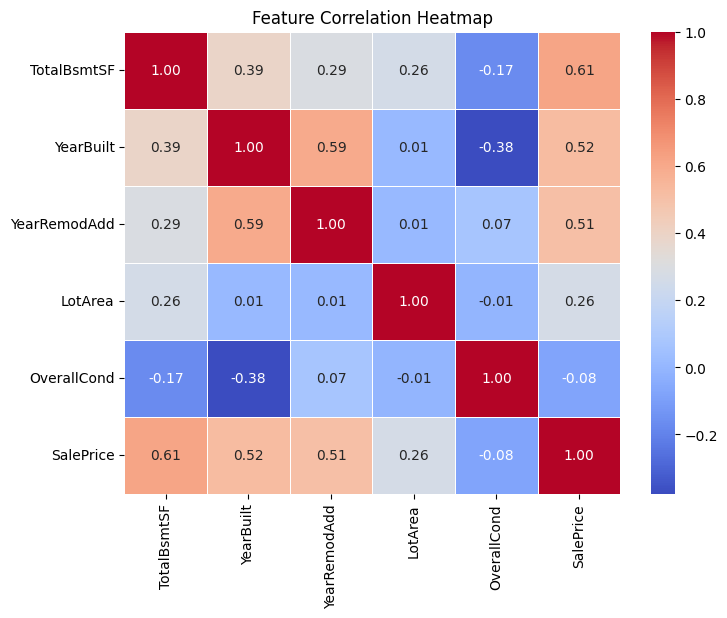

In [55]:
# Correlation Heatmap for your numerical features
plt.figure(figsize=(8, 6))
selected_cols = ['TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'LotArea', 'OverallCond', 'SalePrice']
correlation_matrix = price_data[selected_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()